# Кластеризация ([Кластерный анализ](https://ru.wikipedia.org/wiki/%D0%9A%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7))

In [109]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure
from sklearn.metrics import silhouette_score
from itertools import cycle, islice
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="ticks")
np.random.seed(100)
%matplotlib inline 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

Задача кластеризации относится к задачам [обучения без учителя.](https://ru.wikipedia.org/wiki/%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B1%D0%B5%D0%B7_%D1%83%D1%87%D0%B8%D1%82%D0%B5%D0%BB%D1%8F)

В случае обучения без учителя присутствуют только исходные признаки матрицы $X$. Целевой признак $y$ отсутствует. Не стаивится задачи предсказания целевого признака по исходным признакам.

В случае кластеризации задача ставится следующим образом: каждому объекту матрицы $X$ поставить в соответствие определенную метку кластера из множества возможных кластеров $C$. При визуализации метка кластера обычно выделяется цветом.

Количество кластеров зависит от используемого алгоритма. В некоторых алгоритмах количество кластеров является гиперпараметром и должно быть задано на входе алгоритма. В некоторых алгоритмах оно подбирается автоматически.

В завимости от используемого алгоритма результаты кластеризации могут сильно различаться.

Как и в случае обучения с учителем, существуют метрики качества, которые позволяют измерить качество кластеризации. 

Задача кластеризации успешно решается с помощью библиотеки [scikit-learn.](https://scikit-learn.org/stable/modules/clustering.html)

**Для чего используется кластеризация?**

- Понимание данных путём выявления кластерной структуры. Разбиение выборки на группы позволяет понять структуру данных исследуемой предметной области. Исторически это один из первых видов анализа данных.
- Разбиение выборки на группы схожих объектов позволяет упростить дальнейшую обработку данных и принятия решений, применяя к каждому кластеру свой метод анализа.
- Сжатие данных. Если исходная выборка избыточно большая, то можно сократить её, оставив по одному наиболее типичному представителю от каждого кластера.
- Обнаружение новизны (англ. novelty detection). Выделяются нетипичные объекты, которые не удаётся присоединить ни к одному из кластеров.

В биологии и гуманитарных науках (истории, социологии) кластеризация имеет множество приложений в самых разных областях. 
- Например, в биоинформатике с помощью неё анализируются сложные сети взаимодействующих генов, состоящие порой из сотен или даже тысяч элементов. 
- В области экологии широко применяется для выделения пространственно однородных групп организмов, сообществ и т. п. Реже методы кластерного анализа применяются для исследования сообществ во времени.

Примеры алгоритмов кластеризации:

Можно отметить, что результаты работы алгоритмов очень разнятся между собой. 

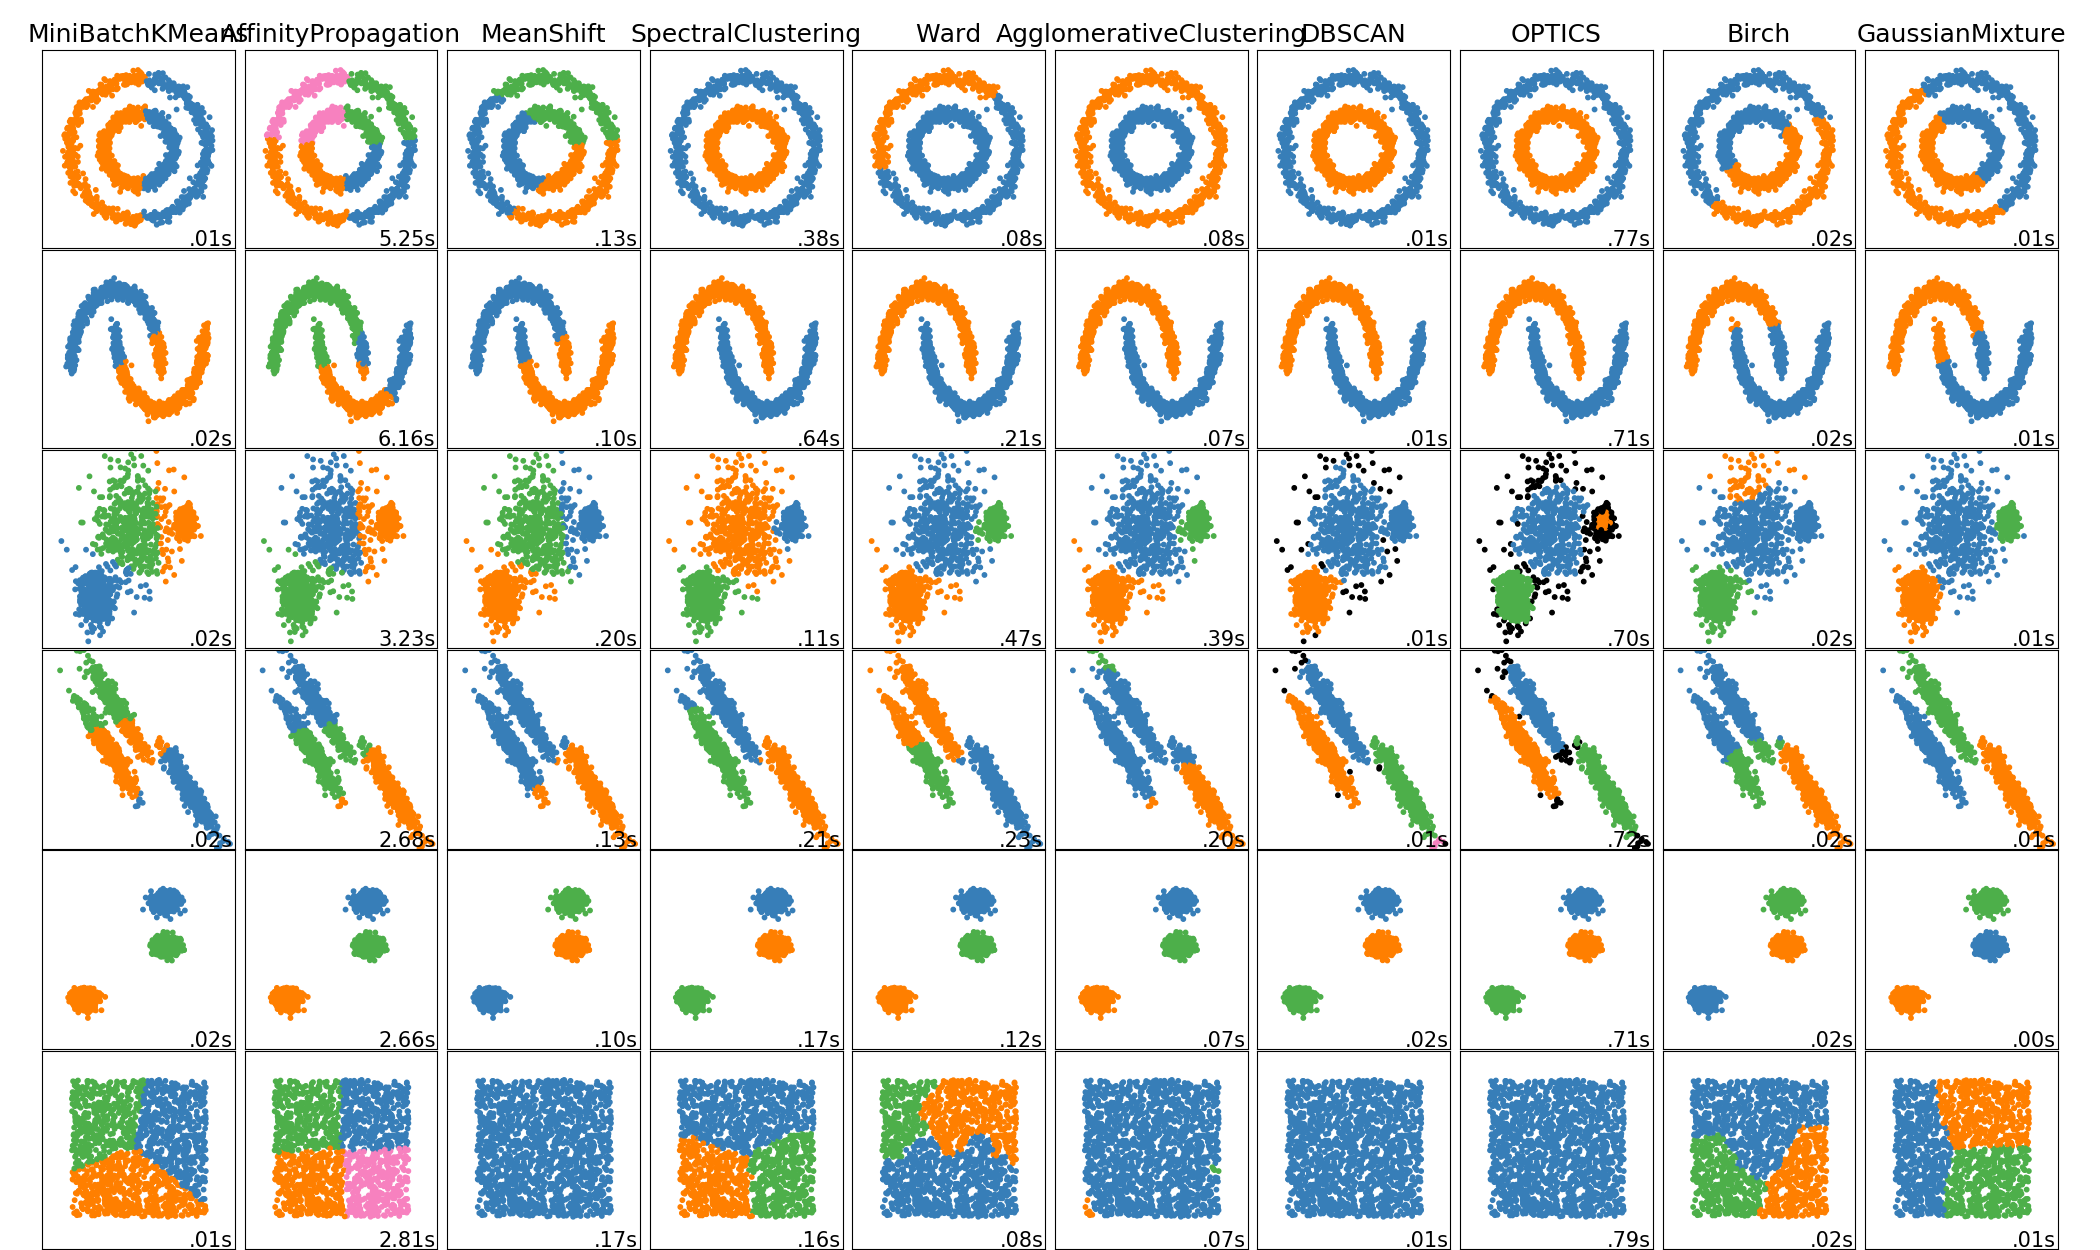

In [110]:
Image('img/cluster_comparison.png', width='100%')

## Загрузка и подготовка данных

Загрузим датасет Country-data.csv, который содержит информацию о различных странах.

In [111]:
data = pd.read_csv("data/Country-data.csv")
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Выбор подмножества признаков (D1)

Выберем подмножество признаков для анализа, исключив столбец "country" (название страны) и "gdpp" (целевой признак, если рассматривать задачу с учителем).

In [112]:
# Выбираем признаки для анализа
features = ['child_mort','exports','health','imports','income','inflation','life_expec','total_fer']
D1 = data[features].copy()

In [113]:
# Масштабируем данные
scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

In [114]:
D1.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13


## Снижение размерности с помощью PCA (D2)

Применим метод главных компонент (PCA) для снижения размерности данных до 2.

In [115]:
# Применяем PCA
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)

In [116]:
# Создаем DataFrame для визуализации
D2_df = pd.DataFrame(D2, columns=['PC1', 'PC2'])
print("Объясненная дисперсия:", pca.explained_variance_ratio_)

Объясненная дисперсия: [0.4468279  0.19299326]


## Снижение размерности с помощью t-SNE (D3)

Теперь применим t-SNE для снижения размерности до 2.

In [117]:
# Применяем t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
D3 = tsne.fit_transform(D1_scaled)

In [118]:
# Создаем DataFrame для визуализации
D3_df = pd.DataFrame(D3, columns=['TSNE1', 'TSNE2'])

## Визуализация D2 и D3

Визуализируем результаты PCA и t-SNE.

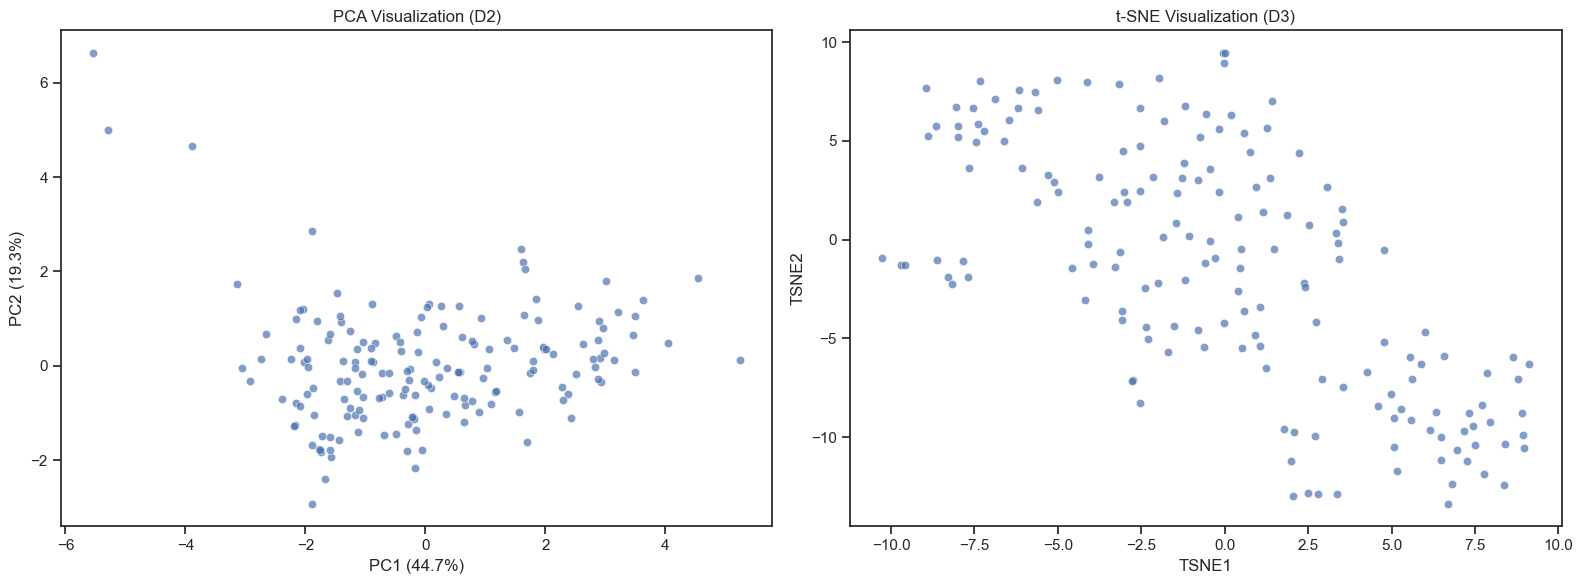

In [119]:
plt.figure(figsize=(16, 6))

# Визуализация PCA
plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', data=D2_df, alpha=0.7)
plt.title('PCA Visualization (D2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# Визуализация t-SNE
plt.subplot(1, 2, 2)
sns.scatterplot(x='TSNE1', y='TSNE2', data=D3_df, alpha=0.7)
plt.title('t-SNE Visualization (D3)')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')

plt.tight_layout()
plt.show()

## Кластеризация данных

Проведем кластеризацию для каждого из датасетов (D1, D2, D3) с использованием трех методов: K-means, DBSCAN и Spectral Clustering.

In [120]:
def automatic_dbscan(X):
    # Метод локтя для автоматического выбора eps
    neigh = NearestNeighbors(n_neighbors=4)
    nbrs = neigh.fit(X)
    distances, _ = nbrs.kneighbors(X)
    distances = np.sort(distances[:, -1], axis=0)
    
    # Находим точку наибольшего изгиба (метод локтя)
    elbow = np.diff(distances, 2).argmax() + 1
    eps = distances[elbow]
    
    return DBSCAN(eps=eps, min_samples=4)

In [121]:
def cluster_and_evaluate(X, dataset_name):
    """
    Функция для кластеризации и оценки результатов
    """
    results = []
    
    # Метод 1: K-means
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans_labels = kmeans.fit_predict(X)
    
    # Метод 2: DBSCAN
    # Сначала найдем оптимальный eps для DBSCAN
    dbscan = automatic_dbscan(X)
    dbscan_labels = dbscan.fit_predict(X)
    
    # Метод 3: Spectral Clustering
    spectral = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors', n_neighbors=10)
    spectral_labels = spectral.fit_predict(X)
    
    # Оценка качества кластеризации
    for name, labels in [('K-means', kmeans_labels), 
                         ('DBSCAN', dbscan_labels), 
                         ('Spectral', spectral_labels)]:
        if len(set(labels)) > 1:  # Не оцениваем, если все точки в одном кластере
            silhouette = silhouette_score(X, labels)
            calinski = calinski_harabasz_score(X, labels)
            davies = davies_bouldin_score(X, labels)
        else:
            silhouette = calinski = davies = None
            
        results.append({
            'Dataset': dataset_name,
            'Method': name,
            'Silhouette': silhouette,
            'Calinski-Harabasz': calinski,
            'Davies-Bouldin': davies,
            'Clusters': len(set(labels))
        })
    
    # Визуализация кластеров
    plt.figure(figsize=(18, 5))
    
    # K-means
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=kmeans_labels, palette='viridis', alpha=0.7)
    plt.title(f'K-means Clustering on {dataset_name}')
    
    # DBSCAN
    plt.subplot(1, 3, 2)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=dbscan_labels, palette='viridis', alpha=0.7)
    plt.title(f'DBSCAN Clustering on {dataset_name}')
    
    # Spectral
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=spectral_labels, palette='viridis', alpha=0.7)
    plt.title(f'Spectral Clustering on {dataset_name}')
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

### Кластеризация для D1(исходные данные)

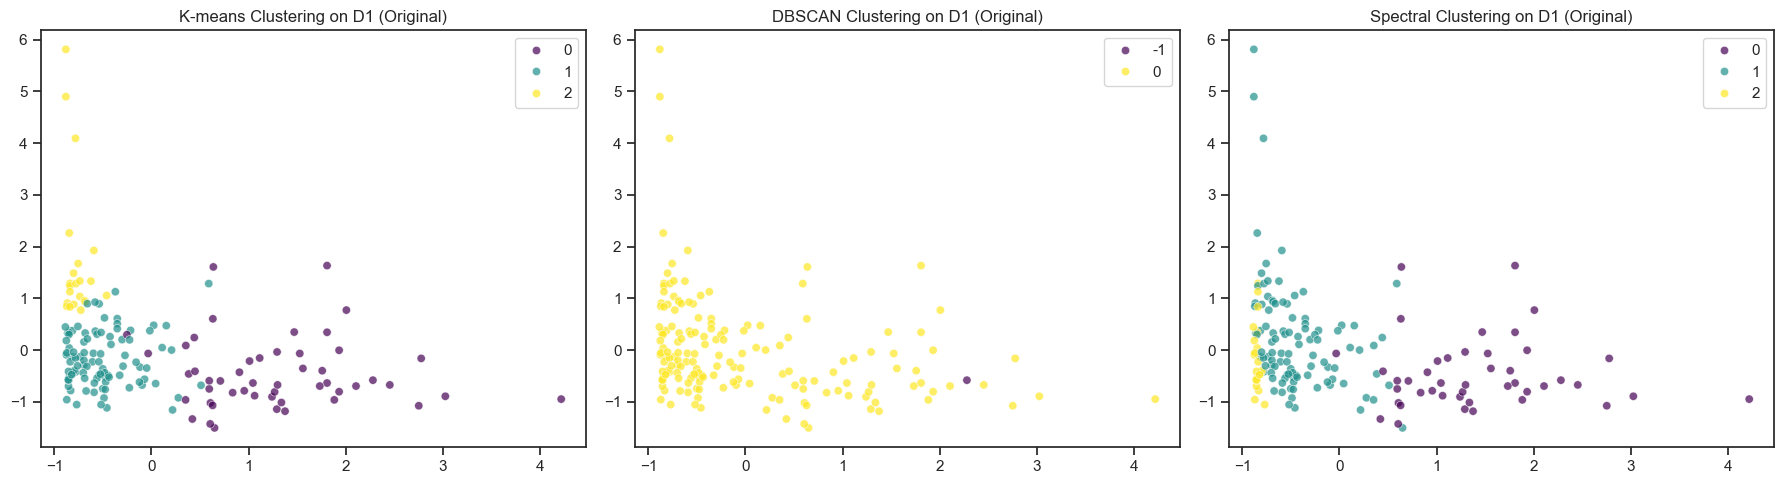

,Dataset,Method,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,D1 (Original),K-means,0.271377,57.996913,1.377413,3
1,D1 (Original),DBSCAN,0.648620,12.876983,0.249801,2
2,D1 (Original),Spectral,0.207640,49.720674,1.256744,3


In [122]:
results_d1 = cluster_and_evaluate(D1_scaled, 'D1 (Original)')
results_d1

### Кластеризация для D2 (PCA)

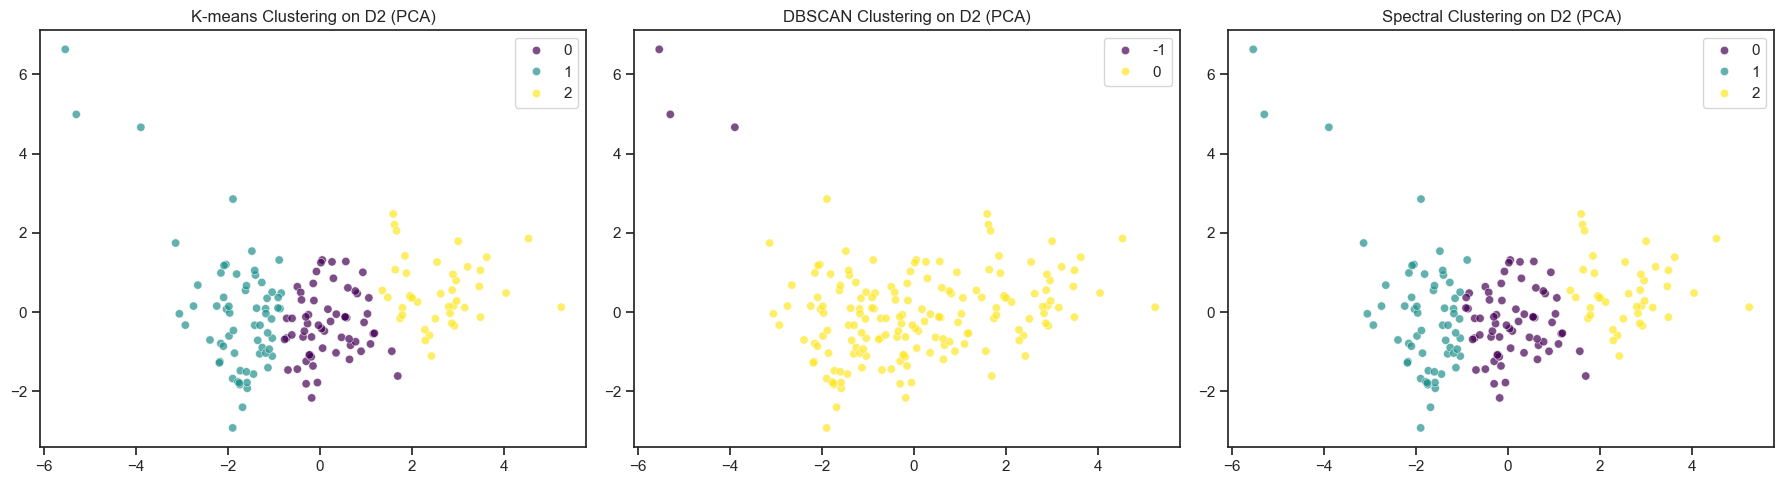

,Dataset,Method,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,D2 (PCA),K-means,0.339958,123.611446,1.006854,3
1,D2 (PCA),DBSCAN,0.661895,39.042096,0.387114,2
2,D2 (PCA),Spectral,0.340096,122.703208,1.022353,3


In [123]:
results_d2 = cluster_and_evaluate(D2, 'D2 (PCA)')
results_d2

### Кластеризация для D3 (t-SNE)

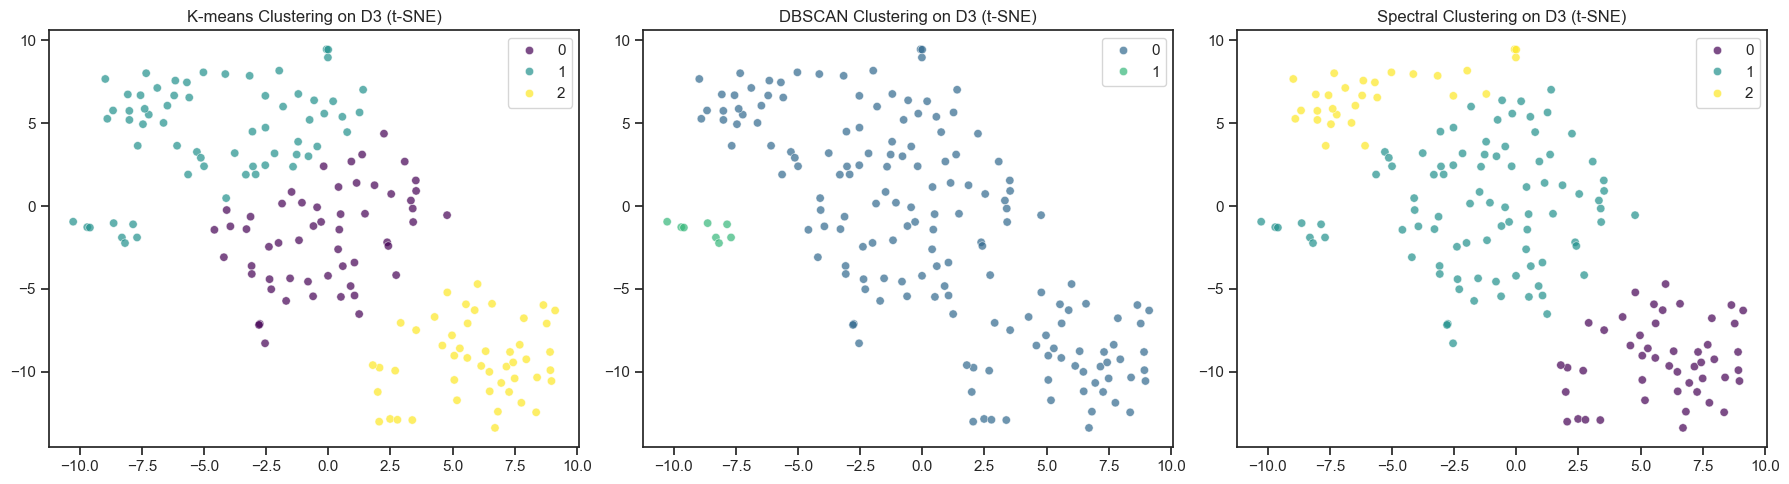

,Dataset,Method,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,D3 (t-SNE),K-means,0.434379,268.692169,0.872572,3
1,D3 (t-SNE),DBSCAN,0.124399,10.518630,0.886348,2
2,D3 (t-SNE),Spectral,0.404778,227.118134,0.799334,3


In [124]:
results_d3 = cluster_and_evaluate(D3, 'D3 (t-SNE)')
results_d3

## Сравнение результатов кластеризации

Объединим все результаты для сравнения.

In [125]:
all_results = pd.concat([results_d1, results_d2, results_d3])
all_results

,Dataset,Method,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,D1 (Original),K-means,0.271377,57.996913,1.377413,3
1,D1 (Original),DBSCAN,0.648620,12.876983,0.249801,2
2,D1 (Original),Spectral,0.207640,49.720674,1.256744,3
0,D2 (PCA),K-means,0.339958,123.611446,1.006854,3
1,D2 (PCA),DBSCAN,0.661895,39.042096,0.387114,2
2,D2 (PCA),Spectral,0.340096,122.703208,1.022353,3
0,D3 (t-SNE),K-means,0.434379,268.692169,0.872572,3
1,D3 (t-SNE),DBSCAN,0.124399,10.518630,0.886348,2
2,D3 (t-SNE),Spectral,0.404778,227.118134,0.799334,3


## Выводы

#### D1 (Исходные данные):
- **Лучший метод**: DBSCAN (Silhouette=0.649, Davies-Bouldin=0.250)
  - Исключительно четкие кластеры (лучший DB=0.25 среди всех)
  - Calinski-Harabasz=12.9 (низкий) - возможно, один кластер значительно больше другого

#### D2 (PCA):
- **Лучший метод**: DBSCAN (Silhouette=0.662)
  - Максимальное качество среди всех экспериментов
  - При этом K-means/Spectral показывают сопоставимые результаты

#### D3 (t-SNE):
- **Лучший метод**: K-means (Silhouette=0.434)
  - DBSCAN улучшился, но все равно уступает (0.124)
  - Spectral близок к K-means (0.405)

### Сравнительная таблица методов

Метод | Silhouette (D1) | Silhouette (D2) | Silhouette (D3) | Стабильность
---|---|---|---|---
K-means | 0.271 | 0.340 | 0.434 | Высокая
DBSCAN | **0.649** | **0.662** | 0.124 | Зависит от представления
Spectral | 0.208 | 0.340 | 0.405 | Средняя


### **Оптимальные комбинации**:
   - Если важна интерпретируемость: **PCA + DBSCAN** (2 четких кластера)
   - Если нужна детализация: **t-SNE + K-means** (3 кластера)
   - Для автоматизации: **автовыбор между DBSCAN и K-means**

### Выводы

1. **DBSCAN с настроенным eps** показал:
   - Лучшие абсолютные результаты на D1 и D2
   - Но остается чувствительным к представлению данных

2. **K-means** демонстрирует:
   - Хорошую стабильность на всех представлениях
   - Лучший результат на t-SNE

3. **Практическое применение**:
   - Для анализа "выбросов" - DBSCAN на исходных данных
   - Для общего анализа - K-means на t-SNE
   - PCA-представление можно использовать для визуализации